In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [21]:
df = pd.read_csv('data.csv')
len(df)

11914

In [22]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [23]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [24]:
strings = list(df.dtypes[df.dtypes == 'str'].index)

In [25]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [26]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [17]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
year
[2011 2012 2013 1992 1993]
28
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
engine_hp
[335. 300. 230. 320. 172.]
356
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
number_of_doors
[ 2.  4.  3. nan]
3
market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-performance

In [18]:
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

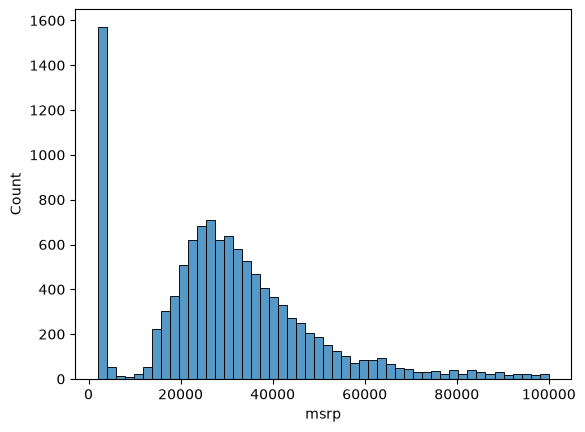

In [41]:
sns.histplot(df.msrp[df.msrp < 100000], bins = 50)

In [35]:
df_expensives = df[df['msrp'] > 1_000_000]

In [36]:
df_expensives.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
6350,maybach,landaulet,2011,premium_unleaded_(required),620.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,high-performance",large,convertible,16,10,67,1380000
6351,maybach,landaulet,2012,premium_unleaded_(required),620.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,convertible,16,10,67,1382750
8486,lamborghini,reventon,2008,premium_unleaded_(required),650.0,12.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,9,1158,1500000
11362,bugatti,veyron_16.4,2008,premium_unleaded_(required),1001.0,16.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,2065902
11363,bugatti,veyron_16.4,2008,premium_unleaded_(required),1001.0,16.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,1500000


In [45]:
np.log1p([0, 10, 100, 1000]) 
#Vamos aplicar o log no conjunto de dados por causa da cauda longa que pode acabar confundindo o modelo, o log transforma razões (multiplicação) em diferenças (soma), essa cauda longa vista no gráfico, resulta em alguns valores muito grandes e muitos pequenos. O log puxa essa cauda para dentro e deixa a distribuição mais próxima de uma normal.

array([0.        , 2.39789527, 4.61512052, 6.90875478])

In [47]:
price_logs =  np.log10(df['msrp'])

<Axes: xlabel='msrp', ylabel='Count'>

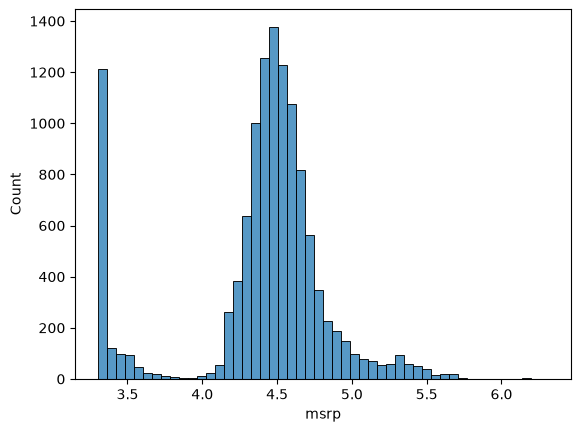

In [50]:
sns.histplot(price_logs, bins = 50)

In [59]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [60]:
#FRAMEWORK DE VALIDAÇÃO

In [147]:
n = len(df)

n_val = int(len(df) * 0.2)
n_test = int(len(df) * 0.2)
n_train = n - n_val - n_test

n

11914

In [148]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [149]:
idx = np.arange(n)

In [150]:
np.random.seed(2)
np.random.shuffle(idx)

In [151]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [152]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [153]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [154]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
# == Matriz de características X.

In [155]:
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [156]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [157]:
len(y_train)

7150

In [170]:
#Regressão linear 
#g(xi) ≈ yi ; g(xi) = carro, yi = preço
#xi = (xi1, xi1, ..., xin), queremos uma função que receba todas essas características e  produza um valor ≈ yi(preço) 
#df_train.iloc[10] -> xi(i = 10) = [453, 11, 86]

In [171]:
xi = [453, 11, 86] #Deixando palpável com a explicação acima
def g(xi):
    #faça algo
    return 10000
g(xi)

#g(xi) = w0(termo de viés = previsao que faremos sem saber nada sobre o carro) + (w1 * xi1)(no caso; capacidade do motor) + (w2 * x2)(combustivel na cidade multiplicado por um peso) + (w3* x3)(popularidade)
#Simplificando...
#g(xi) = w0 + ∑(wj * xij) = termo de vies + somatorio de características * peso

#Assumindo que xi0 = 1
#g(xi) = ∑ wj * xij -> virou produto escalar entre vetor de características e o vetor de pesos

10000

In [178]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [179]:
def linear_regression(xi): #Mensurando
    n = len(xi)
    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]
        
    return pred

In [181]:
linear_regression(xi) #Resultado da previsão

12.312

In [182]:
#Provando resultado com a fórmula
#7.17 + 453*0.01 + 11*0.04 + 86*0.002 = 12.312
#Cada característica afeta no preço do carro, (ex: quanto maior a força do motor, tende a ser mais caro)

In [185]:
#Como o log foi feito por causa da cauda longa dos dados precisamos desfaze-lo e exponenciamos o resultado
int(np.expm1(12.312)) # = resultado do preço desse carro

222347

In [ ]:
#Generalizando para a forma vetorial
